## **Project : Loan Approval Prediction** 

## **Alogorithm : Decision Tree Classifier**

In [1]:
# Step No 1 : Importing Required Libraries 

# Import numerical library 
import numpy as np 

# Import pandas library 
import pandas as pd 

# Import Plot Visulization library 
import matplotlib.pyplot as plt 

# Import Advanced Visulization library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Label Encoder 
from sklearn.preprocessing import LabelEncoder

# Import Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [2]:
# Step No 2 : Loading Dataset 
df = pd.read_csv("loan prediction dataset .csv")

In [3]:
# Step No 3 : Creating Loan_Status Column 
import numpy as np

# Create Total Income
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

# Create Loan Status
df["Loan_Status"] = np.where(
    (
        (df["TotalIncome"] >= 5000)
        &
        (df["LoanAmount"] <= 250)
    ),
    "Y",
    "N"
)

# Check distribution
print(df["Loan_Status"].value_counts())

Loan_Status
N    188
Y    179
Name: count, dtype: int64


In [4]:
# Step No 4 : Data Understanding 

# Display first rows 
print(df.head())

# Display dataset shape 
print(df.shape)

# Display dataset information 
print(df.info())

# Display statistical summary 
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   TotalIncome Loan_Status  
0         5720           Y  
1         4576           N  
2         6800           Y  
3         4886           N  
4         327

In [5]:
# Step No 5 : Data Cleaning 

# Check missing values 
print(df.isnull().sum())

# Fill mising values 
df.fillna(df.mode().iloc[0] , inplace=True)

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicate 
df = df.drop_duplicates()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
TotalIncome           0
Loan_Status           0
dtype: int64
0


In [6]:
# Check missing values 
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
TotalIncome          0
Loan_Status          0
dtype: int64


In [7]:
# Step No 6 : Encode Categorical Data 

# Create Label Encoder object 
encoder = LabelEncoder()

# Encode categorical columns 
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

In [8]:
# Step No 7 : Features and Target 
X = df.drop(
    columns=["Loan_Status"]
)
# Define target variable 
y = df["Loan_Status"]

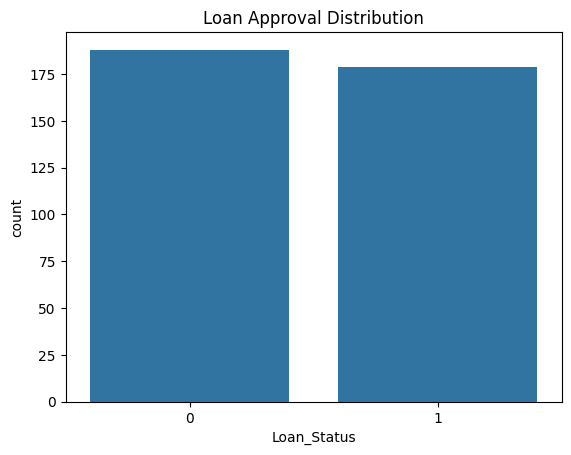

In [9]:
# Step No 8 : Visualization 

# Create Countplot 
sns.countplot(x="Loan_Status" , data= df)

# Set title 
plt.title("Loan Approval Distribution")

# Display Plot 
plt.show()

In [10]:
# Step No 9 : Train Test Split 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 42
)

In [11]:
# Step No : 10 Create Decision Tree Model 
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth= 5,
    random_state= 42
)

In [12]:
# Step No 11 : Train Model 
model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [13]:
# Step No 12 : Prediction
y_pred = model.predict(X_test)

# Display the predicted value 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0
 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1]


In [14]:
# Step No 13 : Evaluation 

# Accuaracy 
print("accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Classification Report 
print("Classification Report : ")
print(classification_report(y_test , y_pred))

# Confusion Matrix
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred)) 

accuracy Score : 
0.972972972972973
Classification Report : 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.97      0.97      0.97        40

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74

Confusion Matrix : 
[[33  1]
 [ 1 39]]


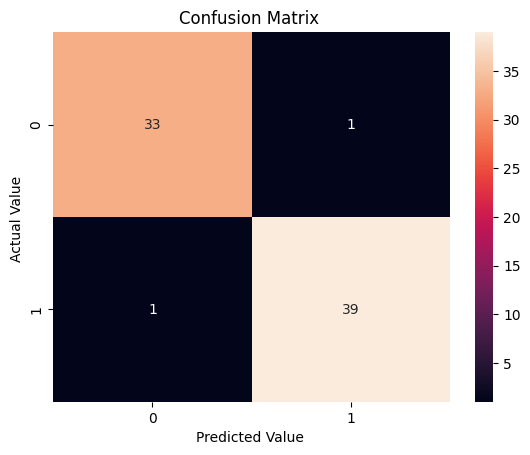

In [15]:
# Step No 14 : Confusion Matrix Visulization 
sns.heatmap(confusion_matrix(y_test , y_pred) , annot= True , fmt = "d")

# Creating title
plt.title("Confusion Matrix ") 

# Creating xlabel 
plt.xlabel("Predicted Value ")

# Creating ylabel 
plt.ylabel("Actual Value ")

# save figure 
plt.savefig("images/Confusion Matrix Visulization(Decision Tree Classifier)")

# Display the output 
plt.show()

In [16]:
# Step No 15 : Feature Importance 
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
print(feature_importance)

              Feature  Importance
0             Loan_ID    0.000000
1              Gender    0.000000
2             Married    0.000000
3          Dependents    0.000000
4           Education    0.011323
5       Self_Employed    0.000000
6     ApplicantIncome    0.000000
7   CoapplicantIncome    0.000000
8          LoanAmount    0.169301
9    Loan_Amount_Term    0.000000
10        TotalIncome    0.819376


In [17]:
# Step No 16 : User Input 
print("\nEnter Applicant Information\n")

Gender = int(input("Gender : "))
Married = int(input("Married : "))
Dependents = int(input("Dependents : "))
Education = int(input("Education : "))
Self_Employed = int(input("Self Employed : "))
ApplicantIncome = float(input("Applicant Income : "))
CoapplicantIncome = float(input("Coapplicant Income : "))
LoanAmount = float(input("Loan Amount : "))
Loan_Amount_Term = float(input("Loan Amount Term : "))




Enter Applicant Information



In [20]:

TotalIncome = (
    ApplicantIncome +
    CoapplicantIncome
)

user_data = pd.DataFrame({

    "Loan_ID":[0],

    "Gender":[Gender],

    "Married":[Married],

    "Dependents":[Dependents],

    "Education":[Education],

    "Self_Employed":[Self_Employed],

    "ApplicantIncome":[ApplicantIncome],

    "CoapplicantIncome":[CoapplicantIncome],

    "LoanAmount":[LoanAmount],

    "Loan_Amount_Term":[Loan_Amount_Term],

    "TotalIncome":[TotalIncome]

})

In [21]:
# Step No 17 : Final Prediction
result = model.predict(
    user_data
)

In [22]:
# Step No 18 : Final Output
if result[0] == 1:

    print("Loan Approved")

else:

    print("Loan Not Approved")

Loan Not Approved
